In [2]:
import json
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})
plt.rcParams.update({
    'font.size': 14,
    'axes.facecolor': '#f0f0f0',
    'figure.facecolor': 'white'
})

(Text(0.5, 0, 'Area (m$^2$)'), Text(0, 0.5, 'LCOW ($/ton)'), None)

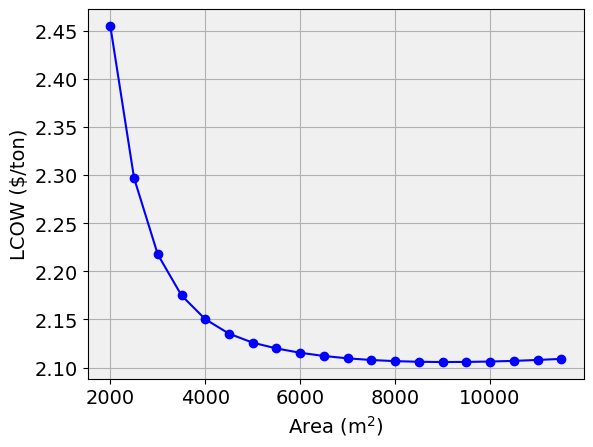

In [5]:
# Read the json
with open('results_fixed_area.json', 'r') as f:
    results=json.load(f)

plt.plot([float(k) for k in results], [v['LCOW'] for v in results.values()], 'bo-')
plt.xlabel('Area (m$^2$)'), plt.ylabel('LCOW ($/ton)'), plt.grid(True)

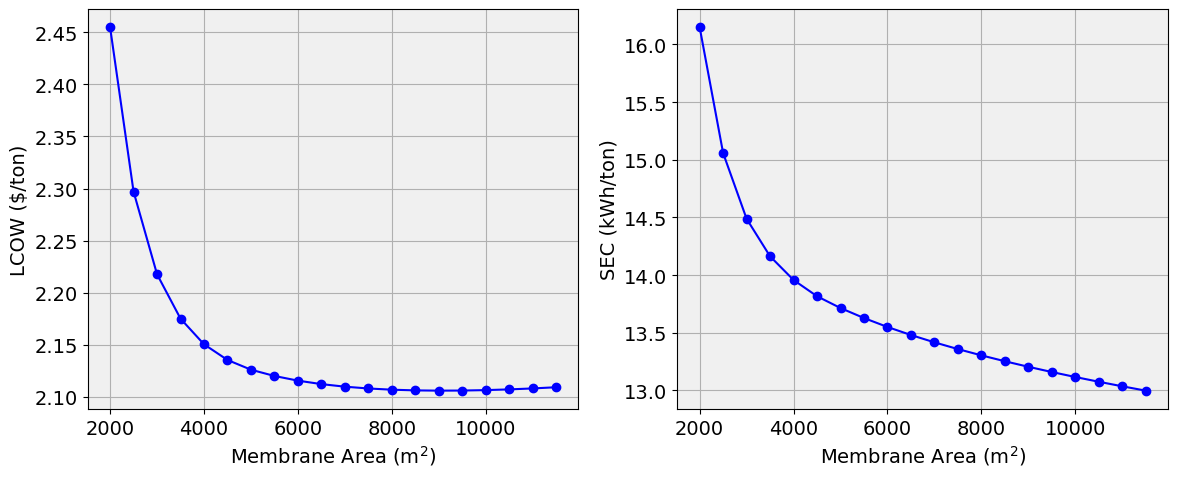

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.plot([float(k) for k in results], [v['LCOW'] for v in results.values()], 'bo-')
ax1.set_xlabel('Membrane Area (m$^2$)')
ax1.set_ylabel('LCOW ($/ton)')
ax1.grid(True)

ax2.plot([float(k) for k in results], [v['SEC'] for v in results.values()], 'bo-')
ax2.set_xlabel('Membrane Area (m$^2$)') 
ax2.set_ylabel('SEC (kWh/ton)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('lcow_sec_constarea.png', dpi=400)

(Text(0.5, 0, 'Area (m$^2$)'), Text(0, 0.5, 'SEC (kWh/ton)'), None)

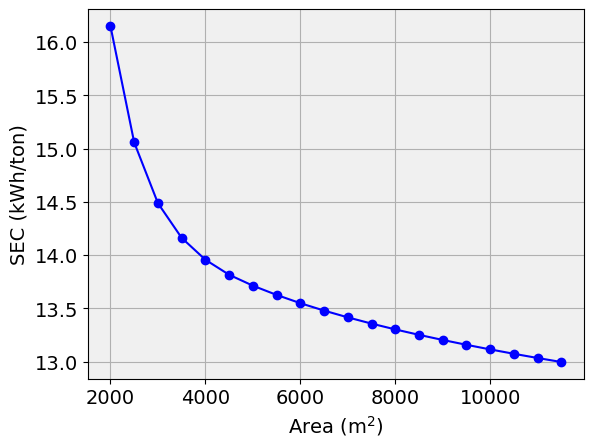

In [66]:
# Read the json
plt.plot([float(k) for k in results], [v['SEC'] for v in results.values()], 'bo-')
plt.xlabel('Area (m$^2$)'), plt.ylabel('SEC (kWh/ton)'), plt.grid(True)

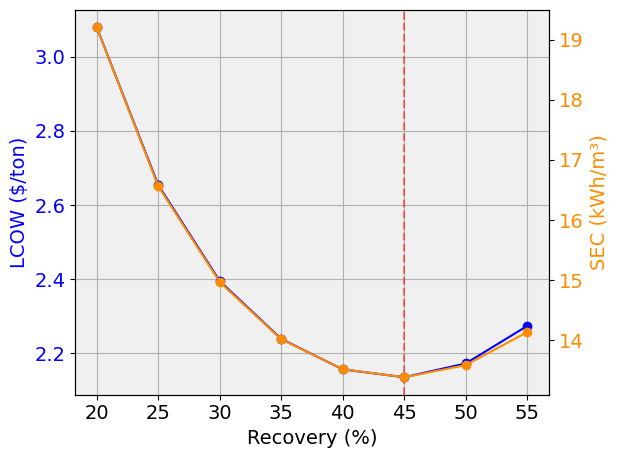

In [7]:
import matplotlib.pyplot as plt

import numpy as np
with open('results_fixed_recovery.json', 'r') as f:
    results = json.load(f)

fig, ax1 = plt.subplots()

# Plot LCOW on primary y-axis
color1 = 'blue'
ax1.plot(np.array([float(k) for k in results])*100, [v['LCOW'] for v in results.values()], 'o-', color=color1)
ax1.set_xlabel('Recovery (%)')
ax1.set_ylabel('LCOW ($/ton)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True)

# Plot SEC on secondary y-axis
ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.plot(np.array([float(k) for k in results])*100, np.array([v['SEC'] for v in results.values()]), 'o-', color=color2)
ax2.set_ylabel('SEC (kWh/m³)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add vertical line at recovery = 0.45
ax1.axvline(x=45, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('lcow_sec_recov.png', dpi = 400)

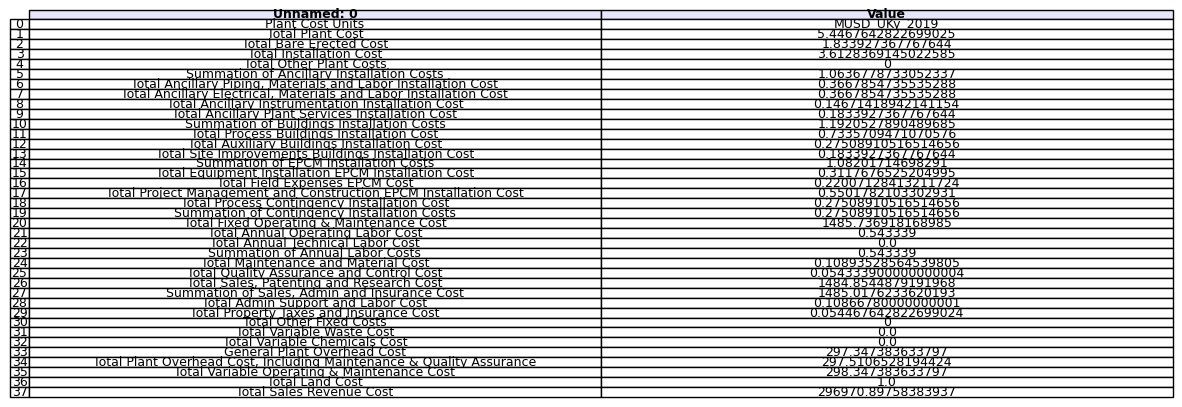

In [10]:
import pandas as pd
from pandas.plotting import table
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('costing2_report.csv')

# Create figure and axis with larger size
fig, ax = plt.subplots(figsize=(12, 8))

# Hide axes
ax.axis('off')

# Create table
tbl = table(ax, df, loc='center')

# Style the table
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)

# Color the header row
for cell in tbl._cells:
    if cell[0] == 0:  # Header row
        tbl._cells[cell].set_facecolor('#E6E6FA')
        tbl._cells[cell].set_text_props(weight='bold')
    else:  # Data rows
        tbl._cells[cell].set_facecolor('white')
    
    # Add borders to all cells
    tbl._cells[cell].set_edgecolor('black')
    tbl._cells[cell].set_text_props(ha='center')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()